## Prepare REAL-COLON Dataset

In [3]:
import os
import pandas as pd
from tqdm import tqdm
import json

lesion_info_file = r'/media/qzhao9/backup/downloads/real-colon/lesion_info.csv'
dataset_root = '/media/qzhao9/新加卷/datasets/real-colon-seg'
img_dir = 'images'
yolo_bbox_dir = 'yolo_bbox'
annot = 'annotations'

lesion_df = pd.read_csv(lesion_info_file)
lesion_info = lesion_df.set_index('unique_object_id')['histology_class'].to_dict()

sub_folders = os.listdir(dataset_root)
print(sub_folders)
df = pd.DataFrame(columns=['img', 'lesion','class'])
file_count = 0
for folder in tqdm(sub_folders, desc='Counting files', disable=False):
    yolo_bbox_full_dir = os.path.join(dataset_root, folder, yolo_bbox_dir)
    bbox_files = os.listdir(yolo_bbox_full_dir)
    file_count += len(bbox_files)

pbar = tqdm(total=file_count, desc='Analyzing dataset', disable=False)

for folder in sub_folders:
    annot_full_dir = os.path.join(dataset_root, folder, annot)
    annot_files = [f for f in os.listdir(annot_full_dir) if f.endswith('.json')]
    for annot_file in annot_files:
        annot_path = os.path.join(annot_full_dir, annot_file)
        try:
            with open(annot_path, 'r') as f:
                annot_data = json.load(f)
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {annot_path}")
            pbar.update(1)
            continue
        img = annot_data['image']
        for entity in annot_data['entities']:
            lesion_id = entity
           
            df = pd.concat([df, pd.DataFrame([{'img': os.path.join(dataset_root, folder, img_dir, img), 
                                                'lesion': lesion_id, 
                                                'class': lesion_info.get(lesion_id, 'UNKNOWN'),
                                                'bbox': os.path.join(dataset_root, folder, yolo_bbox_dir, img.replace('.jpg', '.txt'))
                                               }])], 
                                    ignore_index=True)
        pbar.update(1)

pbar.close()
df.info()


FileNotFoundError: [Errno 2] No such file or directory: '/media/qzhao9/backup/downloads/real-colon/lesion_info.csv'

In [ ]:
df.head()

,img,lesion,class,bbox
0,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
1,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
2,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
3,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
4,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...


In [ ]:
class_count = df.value_counts('class')
print(class_count)
df['class'].describe()

class
HP          103803
AD           85514
NO POLYP     37612
SSL          25256
TSA           9243
OTHER         5659
Name: count, dtype: int64


count     267087
unique         6
top           HP
freq      103803
Name: class, dtype: object

In [ ]:
# find out number of unique images for each lesion class
unique_lesion_counts = df.groupby(by=['class'])['img'].nunique()
print(unique_lesion_counts[unique_lesion_counts > 0])

class
AD          85514
HP          95970
NO POLYP    37612
OTHER        5659
SSL         25256
TSA          9243
Name: img, dtype: int64


In [ ]:
# Sampling and split dataset. test set: 20%, val set: 10%, train set: 70%
import numpy as np
np.random.seed(42)

def copy_files(src_lst, dst, partition):
    dst_part = os.path.join(dst, partition)
    os.makedirs(dst_part, exist_ok=True)
    for src in src_lst:
        if os.path.exists(src):
            os.system(f'cp "{src}" "{os.path.join(dst_part, os.path.basename(src))}"')

keys = df['class'].unique()
print(f"Total unique lesions: {len(keys)}")
target_yolo_dir = '/home/qzhao9/datasets/real-colon-seg/yolo'

img_target_dir = os.path.join(target_yolo_dir, 'images')
os.makedirs(img_target_dir, exist_ok=True)

lbl_target_dir = os.path.join(target_yolo_dir, 'labels')
os.makedirs(lbl_target_dir, exist_ok=True)

img_bbox_map = df.set_index('img')['bbox'].to_dict()

for key in tqdm(keys):
    imgs = df[df['class'] == key]['img'].unique()
    count = imgs.shape[0]
    sample_count = min(3000, count)
    train_count = int(sample_count * 0.7)
    val_count = int(sample_count * 0.1)
    test_count = sample_count - train_count - val_count
    df_lesion = pd.Series(imgs).sample(n=sample_count, random_state=42)
    
    train_set = df_lesion.iloc[:train_count]
    copy_files(train_set, img_target_dir, 'train')
    train_lbls = train_set.map(lambda tr: img_bbox_map[tr])
    copy_files(train_lbls, lbl_target_dir, 'train')
    
    val_set = df_lesion.iloc[train_count:train_count + val_count]
    copy_files(val_set, img_target_dir, 'val')
    val_lbls = val_set.map(lambda tr: img_bbox_map[tr])
    copy_files(val_lbls, lbl_target_dir, 'val')

    test_set = df_lesion.iloc[train_count + val_count:]
    copy_files(test_set, img_target_dir, 'test')
    test_lbls = test_set.map(lambda tr: img_bbox_map[tr])
    copy_files(test_lbls, lbl_target_dir, 'test')
    
    print(f"Lesion {key}: Total={count}, Sampled={sample_count}, Train={train_count}, Val={val_count}, Test={test_count}")


Total unique lesions: 6


 17%|█▋        | 1/6 [02:52<14:20, 172.13s/it]

Lesion AD: Total=85514, Sampled=3000, Train=2100, Val=300, Test=600


 33%|███▎      | 2/6 [05:20<10:32, 158.14s/it]

Lesion HP: Total=95970, Sampled=3000, Train=2100, Val=300, Test=600


...

Lesion OTHER: Total=5659, Sampled=3000, Train=2100, Val=300, Test=600


 83%|████████▎ | 5/6 [13:22<02:37, 157.07s/it]

Lesion SSL: Total=25256, Sampled=3000, Train=2100, Val=300, Test=600


100%|██████████| 6/6 [15:32<00:00, 155.45s/it]

Lesion TSA: Total=9243, Sampled=3000, Train=2100, Val=300, Test=600


In [ ]:
df[df['lesion'].str.startswith('003-004')]['lesion'].value_counts()

lesion
003-004_2    3903
003-004_1    3340
003-004_3    2155
Name: count, dtype: int64

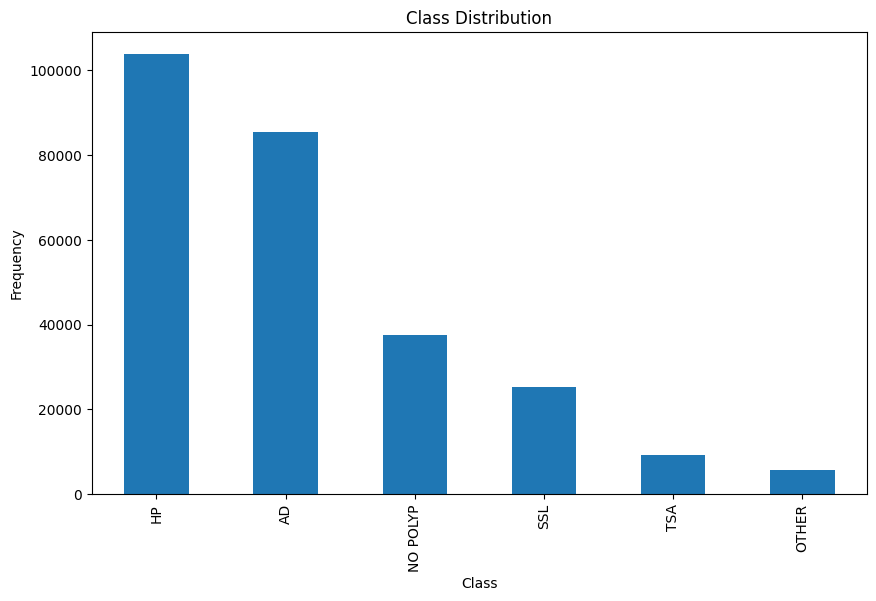

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
class_count.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
class_label_map = {0: 'AD', 1: 'HP', 2: 'NO POLYP', 3: 'OTHER', 4: 'SSL', 5: 'TSA'}

,img,class,x_center,y_center,width,height


In [ ]:
df.head()

,img,lesion,class
0,001-003_9574.jpg,001-003_1,AD
1,001-003_9575.jpg,001-003_1,AD
2,001-003_9576.jpg,001-003_1,AD
3,001-003_9577.jpg,001-003_1,AD
4,001-003_9578.jpg,001-003_1,AD


In [ ]:
# # Prepare Yolo dataset
# import os
# import random

# random.seed(27)

# img_dir = '/home/qzhao9/datasets/real-colon-seg/images'
# yolo_root = '/home/qzhao9/datasets/real-colon-seg/yolo'
# bbox_dir = '/home/qzhao9/datasets/real-colon-seg/yolo_bbox'
# img_train = f'{yolo_root}/images/train/'
# img_val = f'{yolo_root}/images/val/'
# lbl_train = f'{yolo_root}/labels/train/'
# lbl_val = f'{yolo_root}/labels/val/'

# images = os.listdir(img_dir)
# random.shuffle(images)
# train_split = 0.8
# train_size = int(len(images)*train_split)
# train_images = images[:train_size]
# val_images = images[train_size:]
# os.makedirs(img_train, exist_ok=True)
# os.makedirs(img_val, exist_ok=True)
# os.makedirs(lbl_train, exist_ok=True)
# os.makedirs(lbl_val, exist_ok=True)
# for ti in train_images:
#     os.system(f'cp {img_dir}/{ti} {img_train}/{ti}')
#     lbl_name = ti.replace('.jpg','.txt')
#     os.system(f'cp {bbox_dir}/{lbl_name} {lbl_train}/{lbl_name}')
# for vi in val_images:
#     os.system(f'cp {img_dir}/{vi} {img_val}/{vi}')
#     lbl_name = vi.replace('.jpg','.txt')
#     os.system(f'cp {bbox_dir}/{lbl_name} {lbl_val}/{lbl_name}')  

# Add Kvasir-SEG dataset

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np

data_root = '/home/qzhao9/datasets/Kvasir-SEG'

target_yolo_dir = '/home/qzhao9/datasets/real-colon-seg/yolo'

train_list_file = os.path.join(data_root, 'train.txt')

src_img_dir = os.path.join(data_root, 'images')
src_box_dir = os.path.join(data_root, 'bbox')

def copy_files(src_lst, partition):
    for line in src_lst:
        img_name = line.strip()
        img_path = os.path.join(src_img_dir, img_name + '.jpg')
        box_path = os.path.join(src_box_dir, img_name + '.csv')
        if not os.path.exists(box_path):
            print(f"Missing bbox for {img_name}")
        # Convert bbox CSV to YOLO format if needed
        bbox_pd = pd.read_csv(box_path)
        bbox_lines = []
        for index, row in bbox_pd.iterrows():
            x_center = (row['xmin'] + row['xmax']) / 2
            y_center = (row['ymin'] + row['ymax']) / 2
            size = cv2.imread(img_path).shape
            width = size[1]
            height = size[0]
            width_box = row['xmax'] - row['xmin']
            height_box = row['ymax'] - row['ymin']
            bbox_lines.append(f"3 {x_center/width} {y_center/height} {width_box/width} {height_box/height}\n") # Default class 3 (OTHER) for polyp from KVasir-SEG
        yolo_box_path = os.path.join(target_yolo_dir,f'labels/{partition}', 'kv_' + img_name + '.txt')
        with open(yolo_box_path, 'w') as f:
            f.writelines(bbox_lines)
    
        target_img_path =  os.path.join(target_yolo_dir,f'images/{partition}', 'kv_' + img_name + '.jpg')
        os.system(f'cp "{img_path}" "{target_img_path}"')


with open(train_list_file, 'r') as f:
    train_lines = f.readlines()

copy_files(train_lines, 'train')

val_list_file = os.path.join(data_root, 'val.txt')

with open(val_list_file, 'r') as f:
    val_lines = f.readlines()

# split val_lines into two halves: one for val, one for test
np.random.seed(42)
np.random.shuffle(val_lines)
mid_index = len(val_lines) // 2
val_subset = val_lines[:mid_index]
test_subset = val_lines[mid_index:]

copy_files(val_subset, 'val')

copy_files(test_subset, 'test')

# Train Yolo Polyp Detecting model

In [ ]:
# Install or upgrade the ultralytics package from PyPI
%pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 6.5 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 849.8 kB/s  0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 MB 8.6 MB/s  0:00:05m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ultralytics] [ultralytics]n]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
pre_trained_model = 'yolo11n.pt' #'/home/qzhao9/code/9800/gradproj/experiments/runs/detect/train5/weights/best.pt'
model = YOLO(pre_trained_model)

# Display model information (optional)
model.info()



YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

In [ ]:
cfg_file = r"/home/qzhao9/datasets/real-colon-seg/yolo/train_without_augmentation_cfg.yaml"

In [ ]:
import albumentations as A

custom_transforms = A.Compose(
    [A.BBoxSafeRandomCrop(erosion_rate=0.0, p=0.6),
     A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
     A.CLAHE(clip_limit=4.0, p=0.5),
     A.Rotate(limit=90, p=0.5),
     A.ZoomBlur(max_factor=[1.01,1.05], p=0.4),
     A.RandomBrightnessContrast(p=0.5),
     A.Resize(height=768, width=768, p=1.0)],
    bbox_params=A.BboxParams(format="yolo", label_fields=None),
    seed=137,
    strict=True,
)

# results = model.train(data=r"/home/qzhao9/datasets/real-colon-seg/yolo/real-colon.yaml", epochs=100, imgsz=768, batch=16, dropout=0.1)

results = model.train(cfg=cfg_file, augmentations=custom_transforms)

New https://pypi.org/project/ultralytics/8.3.252 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.250 🚀 Python-3.11.4 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 7832MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, augmentations=Compose([
  BBoxSafeRandomCrop(p=0.6, erosion_rate=0.0),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  CLAHE(p=0.5, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)),
  Rotate(p=0.5, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-90.0, 90.0), mask_interpolation=0, rotate_method='largest_box'),
  ZoomBlur(p=0.4, max_factor=(1.01, 1.05), step_factor=(0.01, 0.03)),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Resize(p=1.0, area_for_downscale=None, height=768, interpolation=1, mask_int

/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/albumentations/core/composition.py:720: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.4±55.8 MB/s, size: 312.5 KB)
val: Scanning /home/qzhao9/datasets/real-colon-seg/yolo/labels/val.cache... 1860 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1860/1860 3.4Mit/s 0.0s0s
Plotting labels to /home/qzhao9/code/9800/gradproj/experiments/runs/detect/train_without_augmentation8/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 768 train, 768 val
Using 8 dataloader workers
Logging results to /home/qzhao9/code/9800/gradproj/experiments/runs/detect/train_without_augmentation8
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.24G      1.695      4.981      2.198          8        768: 100% ━━━━━━

/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/albumentations/core/composition.py:720: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/100      3.75G      0.758      0.524      1.191          7        768: 100% ━━━━━━━━━━━━ 843/843 6.1it/s 2:17<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 8.0it/s 7.4s0.1s
                   all       1860       1907      0.931      0.841      0.908      0.702

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/100      3.75G     0.7526     0.5168       1.19          7        768: 100% ━━━━━━━━━━━━ 843/843 6.6it/s 2:08<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 8.7it/s 6.8s0.1s
                   all       1860       1907      0.931      0.841      0.909      0.703

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/100      3.75G     0.7484     0.5177      1.185          7        768

In [ ]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
pre_trained_model = '/home/qzhao9/code/9800/gradproj/experiments/runs/detect/train_without_augmentation8/weights/last.pt'
model = YOLO(pre_trained_model)

In [ ]:
results =model.val(cfg=cfg_file, split='test')

# You can access the metrics directly from the results object
r_dict = results.results_dict
print(f"mAP50-95: {r_dict['metrics/mAP50-95(B)']}")
print(f"Precision: {r_dict['metrics/precision(B)']}")
print(f"Recall: {r_dict['metrics/recall(B)']}")

Ultralytics 8.3.250 🚀 Python-3.11.4 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 7840MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.6 ms, read: 170.0±40.3 MB/s, size: 450.4 KB)
val: Scanning /home/qzhao9/datasets/real-colon-seg/yolo/labels/test... 3660 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3660/3660 508.0it/s 7.2s<0.0s
val: New cache created: /home/qzhao9/datasets/real-colon-seg/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 229/229 13.0it/s 17.6s<0.1s
                   all       3660       3745       0.94      0.851      0.911      0.705
                    AD        601        601      0.883       0.73      0.805      0.576
                    HP        623        671      0.892      0.715      0.816      0.563
               NOPOLYP        607        607       0.98      0.801      0.906     

In [ ]:
results.results_dict

{'metrics/precision(B)': 0.9632871711026397,
 'metrics/recall(B)': 0.8860135395150857,
 'metrics/mAP50(B)': 0.9341585332615887,
 'metrics/mAP50-95(B)': 0.7438330171088765,
 'fitness': 0.7438330171088765}

In [ ]:
import matplotlib.pyplot as plt

pred_results = model([r"/home/qzhao9/datasets/kvasir-dataset/polyps/1fe26727-3cb1-4f94-85a3-acd99a380281.jpg",
                      "/home/qzhao9/datasets/kvasir-dataset/polyps/2ef9c4ad-20f5-471d-86ed-03de964305ff.jpg",
                      "/home/qzhao9/datasets/kvasir-dataset/polyps/9a48d2e8-12a5-43d6-b20f-1dc7852b4443.jpg",
                      '/home/qzhao9/datasets/Kvasir-SEG/images/cju87xn2snfmv0987sc3d9xnq.jpg',
                      '/home/qzhao9/datasets/Kvasir-SEG/images/cju7ea4om2l910801bohqjccy.jpg',
                      "/home/qzhao9/code/adpolyp.png"],
                      save=True)

pred_results[0]
# # Process results list, add all results into one image
# for result in pred_results:
#     boxes = result.boxes  # Boxes object for bounding box outputs
#     masks = result.masks  # Masks object for segmentation masks outputs
#     keypoints = result.keypoints  # Keypoints object for pose outputs
#     probs = result.probs  # Probs object for classification outputs
#     obb = result.obb  # Oriented boxes object for OBB outputs
#     result.show()  # display to screen
#     result.save(filename="result_2.jpg")  # save to disk



0: 768x768 1 OTHER, 7.7ms
1: 768x768 1 OTHER, 7.7ms
2: 768x768 1 HP, 1 OTHER, 7.7ms
3: 768x768 3 OTHERs, 7.7ms
4: 768x768 1 OTHER, 7.7ms
5: 768x768 (no detections), 7.7ms
Speed: 3.0ms preprocess, 7.7ms inference, 0.3ms postprocess per image at shape (1, 3, 768, 768)
Results saved to /home/qzhao9/code/9800/gradproj/experiments/runs/detect/predict7


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'AD', 1: 'HP', 2: 'NOPOLYP', 3: 'OTHER', 4: 'SSL', 5: 'TSA'}
obb: None
orig_img: array([[[1, 3, 3],
        [2, 4, 4],
        [2, 4, 4],
        ...,
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]],

       [[3, 5, 5],
        [3, 5, 5],
        [3, 5, 5],
        ...,
        [4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]],

       [[3, 5, 5],
        [3, 5, 5],
        [3, 5, 5],
        ...,
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]],

       ...,

       [[2, 2, 2],
        [2, 2, 2],
        [2, 2, 2],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [1, 1, 1],
       

# UC Severity Classification
## Dataset: https://zenodo.org/records/5827695
## References:
  
  file:///home/qzhao9/Downloads/applsci-15-07484.pdf

  https://github.com/Nby8/limuc-nets/tree/main
  

In [1]:
# Import necessary packages and libraries
import torchvision
import torch
import numpy as np
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import cv2
import matplotlib.pyplot as plt


# # Load pre-trained model
# vgg_model = torchvision.models.vgg16(pretrained=True)

# # transformation for passing image into the network
# transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# # selecting layers from the model to generate activations
# image_to_heatmaps = nn.Sequential(*list(vgg_model.features[:-4]))

In [ ]:
# def compute_heatmap(model,img):
#   model.eval()
#   # compute logits from the model
#   logits = model(img)
#   # model's prediction 
#   pred = logits.max(-1)[-1]
#   # activations from the model
#   activations = image_to_heatmaps(img)
#   # compute gradients with respect to the model's most confident prediction
#   logits[0, pred].backward(retain_graph=True)
#   # average gradients of the featuremap 
#   pool_grads = model.features[-3].weight.grad.data.mean((0,2,3))
#   # multiply each activation map with corresponding gradient average
#   for i in range(activations.shape[1]):
#     activations[:,i,:,:] *= pool_grads[i]
#   # calculate mean of weighted activations
#   heatmap = torch.mean(activations, dim=1)[0].cpu().detach()
#   return heatmap, pred


# def upsampleHeatmap(map, image):
#   # permute image
#   # image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
#   image = np.array(image.resize((224,224)) )
#   # maximum and minimum value from heatmap
#   m, M = map.min(), map.max()
#   # normalize the heatmap
#   map = 255 * ((map-m)/ (m-M))
#   map = np.uint8(map)
#   # resize the heatmap to the same as the input
#   map = cv2.resize(map, (224, 224))
#   map = cv2.applyColorMap(255-map, cv2.COLORMAP_JET)
#   map = np.uint8(map)
#   # change this to balance between heatmap and image
#   map = np.uint8(map*0.4 + image*0.6)
#   return map


In [ ]:
# # Example usage
# cat_dog_img = "/home/qzhao9/Pictures/cat_dog.jpg"
# orig_img = Image.open(cat_dog_img)
# cat_dog_img = transform(orig_img)

# cat_dog_img = cat_dog_img.unsqueeze(0)
# heatmap,pred = compute_heatmap(vgg_model,cat_dog_img)
# upsampled_map = upsampleHeatmap(heatmap, orig_img)
# print(f"Prediction: {pred}")

# display_images(upsampled_map, orig_img.resize((224,224)))

Prediction: tensor([284])


<Figure size 1000x500 with 2 Axes>

In [ ]:
# import os
# import numpy as np
# from PIL import Image
# from tqdm import tqdm

# dataset_dir = '/home/qzhao9/datasets/LIMUC/train'
# cls_folders = os.listdir(dataset_dir)

# all_means = []
# all_stds = []

# for cls in tqdm(cls_folders, desc='Processing classes'):
#     cls_path = os.path.join(dataset_dir, cls)
#     imgs = os.listdir(cls_path)
    
#     for img in imgs:
#         img_path = os.path.join(cls_path, img)
#         try:
#             # Open image and convert to RGB
#             image = Image.open(img_path).convert('RGB')
#             # Convert to numpy array and normalize to [0, 1]
#             img_array = np.array(image) / 255.0
            
#             # Calculate mean and std for each channel
#             mean = np.mean(img_array, axis=(0, 1))
#             std = np.std(img_array, axis=(0, 1))
            
#             all_means.append(mean)
#             all_stds.append(std)
#         except Exception as e:
#             print(f"Error processing {img_path}: {e}")
#             continue

# # Calculate overall mean and std across all images
# overall_mean = np.mean(all_means, axis=0)
# overall_std = np.mean(all_stds, axis=0)

# print(f"Overall Mean (R, G, B): {overall_mean}")
# print(f"Overall Std (R, G, B): {overall_std}")

Processing classes: 100%|██████████| 4/4 [00:52<00:00, 13.07s/it]

Overall Mean (R, G, B): [    0.41425     0.28769     0.21844]
Overall Std (R, G, B): [    0.28676     0.20849     0.16271]


In [4]:
import torch
import albumentations as A
import torchvision.transforms as T
from ultralytics.data.dataset import ClassificationDataset
from ultralytics.models.yolo.classify import ClassificationTrainer, ClassificationValidator

# custom_transforms = A.Compose(
#     [
#      A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
#      A.CLAHE(clip_limit=4.0, p=0.5),
#      A.Rotate(limit=90, p=0.5),
#      A.ZoomBlur(max_factor=[1.01,1.05], p=0.4),
#      A.RandomBrightnessContrast(p=0.5),
#      A.Resize(height=288, width=352, p=1.0),
#      A.Normalize(mean=(0.41,0.29,0.22), std=(0.29,0.21,0.16))],
     
#     seed=137,
#     strict=True,
# )


# val_transforms = A.Compose(
#     [
#      A.Resize(height=288, width=352, p=1.0),
#      A.Normalize(mean=(0.41,0.29,0.22), std=(0.29,0.21,0.16)),],
     
#     seed=137,
#     strict=True,
# )

class CustomizedDataset(ClassificationDataset):
    """A customized dataset class for image classification with enhanced data augmentation transforms."""

    def __init__(self, root: str, args, augment: bool = False, prefix: str = ""):
        """Initialize a customized classification dataset with enhanced data augmentation transforms."""
        super().__init__(root, args, augment, prefix)

        # Add your custom training transforms here
        train_transforms = T.Compose(
            [
                T.Resize((args.imgsz, args.imgsz)),
                T.RandomHorizontalFlip(p=args.fliplr),
                T.RandomVerticalFlip(p=args.flipud),
                T.RandAugment(interpolation=T.InterpolationMode.BILINEAR),
                T.ColorJitter(brightness=args.hsv_v, contrast=args.hsv_v, saturation=args.hsv_s, hue=args.hsv_h),
                T.ToTensor(),
                # T.Normalize(mean=torch.tensor([0.41,0.29,0.22]), std=torch.tensor([0.299,0.22,0.18])),
                T.RandomErasing(p=args.erasing, scale=(0.02, 0.1), inplace=True),
            ]
        )

        # Add your custom validation transforms here
        val_transforms = T.Compose(
            [
                # T.Resize((args.imgsz, args.imgsz)),
                T.ToTensor(),
                # T.Normalize(mean=torch.tensor([0.41,0.29,0.22]), std=torch.tensor([0.299,0.22,0.18])),
                # T.Normalize(mean=torch.tensor(0.5), std=torch.tensor(0.5)),
            ]
        )
        
        self.torch_transforms = train_transforms if augment else val_transforms
        # self.torch_transforms = custom_transforms if augment else val_transforms


class CustomizedTrainer(ClassificationTrainer):
    """A customized trainer class for YOLO classification models with enhanced dataset handling."""

    def build_dataset(self, img_path: str, mode: str = "train", batch=None):
        """Build a customized dataset for classification training and the validation during training."""
        return CustomizedDataset(root=img_path, args=self.args, augment=mode == "train", prefix=mode)


class CustomizedValidator(ClassificationValidator):
    """A customized validator class for YOLO classification models with enhanced dataset handling."""

    def build_dataset(self, img_path: str, mode: str = "train"):
        """Build a customized dataset for classification standalone validation."""
        return CustomizedDataset(root=img_path, args=self.args, augment=mode == "train", prefix=self.args.split)




In [5]:
from ultralytics import YOLO

dataset_dir = '/home/qzhao9/datasets/LIMUC'
# model_name = '"yolo11n-cls.pt"
# model_name = '/home/qzhao9/code/9800/gradproj/experiments/runs/classify/train2/weights/best.pt'
size = 'x'
model_name = f'/home/qzhao9/datasets/LIMUC/pre_models/yolo26{size}-cls.pt'
# Load a model
model = YOLO(model_name)  # load a pretrained model (recommended for training)

# Train the model
train_results = model.train(data=dataset_dir, 
                            trainer=CustomizedTrainer, 
                            epochs=200, 
                            imgsz=288,
                            fliplr=0.7,
                            flipud=0.7,
                            erasing=0.1, 
                            dropout=0.1, 
                            patience=0,
                            seed=47,
                            lr0=0.00005, 
                            lrf=0.0001,
                            cos_lr=True,
                            optimizer='SGD',                    
                            name=f'uc-clf_26{size}_non_normalized'
                            ) #(cfg='/home/qzhao9/Downloads/LIMUC/train_without_augmentation_cfg.yaml')

New https://pypi.org/project/ultralytics/8.4.5 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.250 🚀 Python-3.11.4 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 7840MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/qzhao9/datasets/LIMUC, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=200, erasing=0.1, exist_ok=False, fliplr=0.7, flipud=0.7, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=288, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/qzhao9/datasets/LIMUC/pre_models/yolo26x-cls.pt, momentum=0.937, mosai

In [7]:
best_model_path = f'{train_results.save_dir}/weights/last.pt'
print('Model:', best_model_path)
model = YOLO(best_model_path)
model.val(data='/home/qzhao9/datasets/LIMUC',validator=CustomizedValidator, imgsz=288, split='test')

Model: /home/qzhao9/code/9800/gradproj/experiments/runs/classify/uc-clf_26x_non_normalized/weights/last.pt
Ultralytics 8.3.250 🚀 Python-3.11.4 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 7840MiB)
YOLO26x-cls summary (fused): 94 layers, 28,337,540 parameters, 0 gradients, 110.3 GFLOPs
train: /home/qzhao9/datasets/LIMUC/train... found 9590 images in 4 classes ✅ 
val: None...
test: /home/qzhao9/datasets/LIMUC/test... found 1686 images in 4 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6626.8±2266.0 MB/s, size: 297.1 KB)
test: Scanning /home/qzhao9/datasets/LIMUC/test... 1686 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1686/1686 4.2Mit/s 0.0s0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 106/106 16.8it/s 6.3s0.1s
                   all      0.772          1
Speed: 0.3ms preprocess, 3.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/qzhao9/code/9800/gradproj/experiments/runs/classify/val27


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7214f292f850>
curves: []
curves_results: []
fitness: 0.88612100481987
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.77224200963974, 'metrics/accuracy_top5': 1.0, 'fitness': 0.88612100481987}
save_dir: PosixPath('/home/qzhao9/code/9800/gradproj/experiments/runs/classify/val27')
speed: {'preprocess': 0.25322173783299595, 'inference': 3.2373937520655174, 'loss': 0.0007429673698051885, 'postprocess': 0.0016035165968196396}
task: 'classify'
top1: 0.77224200963974
top5: 1.0

## Model Evaluation

In [1]:
%matplotlib inline

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 8.3 MB/s  0:00:016m0:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=12fef664eceb6273426d6cd05a82aeee0e910763fc75dfc6c6a8ed22ac7078db
  Stored in directory: /home/qzhao9/.cache/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]1/2 [grad-cam]


In [1]:
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns   
import os
import numpy as np
from PIL import Image
import evaluate
import torchvision.transforms as T

np.random.seed(42)

img_path = '/home/qzhao9/datasets/LIMUC/test'

lbls ={0:'Mayo 0', 1:'Mayo 1', 2:'Mayo 2', 3:'Mayo 3'}

def calculate_metrics_hf(image_processor, model, img_path, model_name):
    y = []
    y_pred = []
    btsz = 4
    if 'shortest_edge' in image_processor.size:
        size = (image_processor.size['shortest_edge'],image_processor.size['shortest_edge'])
    else:
        size = (image_processor.size["height"], image_processor.size["width"])
    # size = (model.config.image_size, model.config.image_size)
    metric = evaluate.load("accuracy")
    val_transforms = T.Compose(
        [
            T.Resize(size),
            T.ToTensor(),
        ]
    )
    for key, value in lbls.items():
        folder = os.path.join(img_path, value)
        img_files = os.listdir(folder)
        np.random.shuffle(img_files)
        # img_files = np.random.choice(img_files, min(500, len(img_files)), replace=False)
        test_data = []
        batch_start = len(y)
        for img_file in img_files:
            test_data.append(os.path.join(folder, img_file))
            y.append(key)

        for i in range(0, len(test_data), btsz):
            batch_data = test_data[i:i+btsz]
            # val_transforms()
            # input = image_processor(images=[Image.open(p).convert('RGB').resize((224,224)) for p in batch_data], return_tensors="pt")
            # input =val_transforms
            pixel_values = [val_transforms(Image.open(p).convert("RGB")) for p in batch_data]
            input = {'pixel_values': torch.stack(pixel_values)}
            # print(input['pixel_values'].shape)
            input = {k: v.to(device='cuda',dtype=torch.float) for k, v in input.items()}
            output = model(**input)
            # print(output)
            predicted_class_idx = output.logits.argmax(-1).tolist()
            y_pred.extend(predicted_class_idx)
            metric.add_batch(
                predictions=predicted_class_idx,
                references=y[batch_start+i:batch_start+i+len(batch_data)],
            )
    eval_metric = metric.compute()
    print(f"Accuracy: {eval_metric['accuracy']}")        
    _calc_metrics(model_name, lbls, y, y_pred)
    

def calculate_metrics_yolo(model, img_path, model_name):
    y = []
    y_pred = []
    btsz = 100
    for key, value in lbls.items():
        folder = os.path.join(img_path, value)
        img_files = os.listdir(folder)
        np.random.shuffle(img_files)
        # img_files = np.random.choice(img_files, min(500, len(img_files)), replace=False)
        test_data = []
        for img_file in img_files:
            test_data.append(os.path.join(folder, img_file))
            y.append(key)

        for i in range(0, len(test_data), btsz):
            batch_data = test_data[i:i+btsz]
            pre_results = model(batch_data, imgsz=288, save=False,stream=True)
            for res in pre_results:
                res.to(device='cpu')
                y_pred.append(res.probs.top1)
            
    _calc_metrics(model_name, lbls, y, y_pred)

def _calc_metrics(model_name, lbls, y, y_pred):
    kappa_score = cohen_kappa_score(y, y_pred, weights='quadratic')
    print(f"Cohen's Kappa Score: {kappa_score}")

    confusion_matrix_score = confusion_matrix(y, y_pred)
    print(f"Confusion Matrix for {model_name}:")
    print(confusion_matrix_score)
    normal_conf_score = confusion_matrix_score/confusion_matrix_score.sum(axis=1, keepdims=True)
    print(f"Normalized Confusion Matrix for {model_name}:")
    print(normal_conf_score)
    classification_report_str = classification_report(y, y_pred, target_names=lbls.values())
    print(f"Classification Report for {model_name}:")
    print(classification_report_str)
    # display confusion matrix as heatmap
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.heatmap(normal_conf_score, annot=True, fmt='.3f', cmap='Blues', xticklabels=lbls.values(), yticklabels=lbls.values(), ax=axes[0])
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    axes[0].set_title(f"Normalized Confusion Matrix for {model_name}")
    axes[1].axis('off')
    axes[1].set_title("Kappa Score: {:.3f}".format(kappa_score))
    # Write classification report on the second subplot
    axes[1].text(0.1, 0.5, classification_report_str, fontsize=10, va='center')
    plt.savefig(f'images/confusion_matrix_{model_name}.png')
    plt.show()


def display_images(upsampled_map, image):
    # image = image.squeeze(0).permute(1, 2, 0)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(upsampled_map)
    axes[0].set_title("Heatmap")
    axes[0].axis('off')
    axes[1].imshow(image)
    # Create an overlay of the heatmap on the original image
    # convert PIL image to numpy array
    # image_np = image.cpu().numpy()
    # print(image_np.dtype, upsampled_map.dtype)
    
    # overlay = cv2.addWeighted(image_np, 0.6, upsampled_map, 0.4, 0)
    # axes[1].imshow(overlay)
    axes[1].set_title("Original Image")
    axes[1].axis('off')
    plt.show()

In [9]:
from ultralytics import YOLO
import gc
import time
import torch

model_name = "yolo11n-cls.pt"
# model_name = '/home/qzhao9/code/9800/gradproj/experiments/runs/classify/uc-clf_26n/weights/best.pt'
# # Load a model
# model = YOLO(model_name)  # load a pretrained model (recommended for training)

# yolo_seq_model = model.model.model
sizes = ['x_non_normalized','x_normalized','x_normalized2'] #['n','s','m','l','x']
model_names = [(f'/home/qzhao9/code/9800/gradproj/experiments/runs/classify/uc-clf_26{size}/weights/best.pt',f'YOLO26{size}-cls') 
               for size in sizes]
for model_path, model_name in model_names:
# size = 'x'  # choose from 'n', 's', 'm', 'l', 'x'
# model_path = f'/home/qzhao9/code/9800/gradproj/experiments/runs/classify/uc-clf_26{size}/weights/best.pt'
# model_name = f'YOLO26{size}-cls'
    print(f"*********Evaluating model: {model_name}***********")
    model = YOLO(model_path)  # load a pretrained model (recommended for training)
    calculate_metrics_yolo(model, img_path, model_name)
    # model.to(device='cpu')
    model = None  # free up memory
    # print(torch.cuda.mem_get_info())
    torch.cuda.empty_cache()
    time.sleep(5)
    gc.collect()
    time.sleep(5)
    gc.collect()

*********Evaluating model: YOLO26x_non_normalized-cls***********

0: 288x352 Mayo 0 0.99, Mayo 1 0.01, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
1: 288x352 Mayo 1 0.67, Mayo 0 0.33, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
2: 288x352 Mayo 0 0.98, Mayo 1 0.02, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
3: 288x352 Mayo 0 0.99, Mayo 1 0.01, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
4: 288x352 Mayo 1 0.67, Mayo 0 0.31, Mayo 2 0.02, Mayo 3 0.00, 3.7ms
5: 288x352 Mayo 0 0.84, Mayo 1 0.16, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
6: 288x352 Mayo 0 0.71, Mayo 1 0.29, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
7: 288x352 Mayo 0 0.91, Mayo 1 0.09, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
8: 288x352 Mayo 0 1.00, Mayo 1 0.00, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
9: 288x352 Mayo 0 0.69, Mayo 1 0.31, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
10: 288x352 Mayo 0 0.99, Mayo 1 0.01, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
11: 288x352 Mayo 0 1.00, Mayo 1 0.00, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
12: 288x352 Mayo 1 0.60, Mayo 0 0.40, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
13: 288x352 Mayo 0 0.99, Mayo 1 0.

<Figure size 1000x500 with 3 Axes>

*********Evaluating model: YOLO26x_normalized-cls***********

0: 288x352 Mayo 1 0.67, Mayo 0 0.31, Mayo 2 0.02, Mayo 3 0.00, 3.7ms
1: 288x352 Mayo 0 0.60, Mayo 1 0.38, Mayo 2 0.02, Mayo 3 0.00, 3.7ms
2: 288x352 Mayo 0 0.89, Mayo 1 0.11, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
3: 288x352 Mayo 0 0.86, Mayo 1 0.14, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
4: 288x352 Mayo 0 0.97, Mayo 1 0.03, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
5: 288x352 Mayo 0 0.69, Mayo 1 0.31, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
6: 288x352 Mayo 0 0.67, Mayo 1 0.33, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
7: 288x352 Mayo 1 0.58, Mayo 0 0.39, Mayo 2 0.03, Mayo 3 0.01, 3.7ms
8: 288x352 Mayo 0 0.99, Mayo 1 0.01, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
9: 288x352 Mayo 0 0.89, Mayo 1 0.11, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
10: 288x352 Mayo 0 0.57, Mayo 1 0.39, Mayo 2 0.03, Mayo 3 0.00, 3.7ms
11: 288x352 Mayo 1 0.53, Mayo 0 0.41, Mayo 2 0.06, Mayo 3 0.01, 3.7ms
12: 288x352 Mayo 0 0.88, Mayo 1 0.12, Mayo 2 0.00, Mayo 3 0.00, 3.7ms
13: 288x352 Mayo 0 0.77, Mayo 1 0.23, 

<Figure size 1000x500 with 3 Axes>

*********Evaluating model: YOLO26x_normalized2-cls***********

0: 288x352 Mayo 0 0.98, Mayo 1 0.02, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
1: 288x352 Mayo 0 0.99, Mayo 1 0.01, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
2: 288x352 Mayo 0 0.95, Mayo 1 0.05, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
3: 288x352 Mayo 0 0.93, Mayo 1 0.07, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
4: 288x352 Mayo 0 0.70, Mayo 1 0.28, Mayo 2 0.02, Mayo 3 0.00, 3.5ms
5: 288x352 Mayo 1 0.62, Mayo 0 0.37, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
6: 288x352 Mayo 0 0.59, Mayo 1 0.41, Mayo 2 0.01, Mayo 3 0.00, 3.5ms
7: 288x352 Mayo 0 0.80, Mayo 1 0.20, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
8: 288x352 Mayo 0 0.75, Mayo 1 0.25, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
9: 288x352 Mayo 0 0.99, Mayo 1 0.01, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
10: 288x352 Mayo 1 0.57, Mayo 0 0.42, Mayo 2 0.01, Mayo 3 0.00, 3.5ms
11: 288x352 Mayo 0 0.77, Mayo 1 0.23, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
12: 288x352 Mayo 0 0.66, Mayo 1 0.34, Mayo 2 0.00, Mayo 3 0.00, 3.5ms
13: 288x352 Mayo 1 0.64, Mayo 0 0.36,

<Figure size 1000x500 with 3 Axes>

In [13]:
import torchvision.transforms as T
from sklearn.metrics import cohen_kappa_score
import numpy as np
import PIL.Image as Image
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch

img_path = '/home/qzhao9/datasets/LIMUC/test/Mayo 3/UC_patient_44_8.bmp'
size='x_non_normalized'
model_path=f'/home/qzhao9/code/9800/gradproj/experiments/runs/classify/uc-clf_26{size}/weights/best.pt'

model = YOLO(model_path)
yolo_seq_model = model.model.model
yolo_seq_model[10].conv.conv.weight.requires_grad = True
print(yolo_seq_model[10].conv.conv.weight.requires_grad)

results = model(img_path, imgsz=288,save=False)
top1_pred = results[0].probs.top1
print('\nPredicted Severity:', results[0].names[top1_pred])
lbl = results[0].probs.top1
target_layer = yolo_seq_model[10].conv
target_layers = [target_layer]
targets = [ClassifierOutputTarget(lbl)]

img = np.array(Image.open(img_path).convert('RGB'))
# img = cv2.resize(img, (480, 480))
rgb_img = img.copy()
img = np.float32(img) / 255
transform = T.Compose(
            [
                # T.Resize((288, 288)),
                T.ToTensor(),
                # T.Normalize(mean=torch.tensor(0), std=torch.tensor(1)),
            ])
input_tensor = transform(Image.open(img_path).convert('RGB')).unsqueeze(0)
model.eval()
if not target_layer.conv.weight.requires_grad:
  target_layer.conv.weight.requires_grad = True

with GradCAM(model=model.model, target_layers=target_layers) as cam:
  # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  # In this example grayscale_cam has only one image in the batch:
  grayscale_cam = grayscale_cam[0, :]
  visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True, image_weight=0.8)
  # You can also get the model outputs without having to redo inference
  model_outputs = cam.outputs


display_images(Image.fromarray(visualization), rgb_img)

True

image 1/1 /home/qzhao9/datasets/LIMUC/test/Mayo 3/UC_patient_44_8.bmp: 288x352 Mayo 3 0.98, Mayo 2 0.02, Mayo 1 0.00, Mayo 0 0.00, 6.0ms
Speed: 0.8ms preprocess, 6.0ms inference, 0.1ms postprocess per image at shape (1, 3, 288, 352)

Predicted Severity: Mayo 3


NameError: name 'display_images' is not defined

In [15]:
model.names

{0: 'Mayo 0', 1: 'Mayo 1', 2: 'Mayo 2', 3: 'Mayo 3'}

# Other MOdel

['google_vit-base-patch16-224', 'microsoft_resnet-50', 'google_mobilenet_v2_1.0_224', 'nvidia_mit-b2', 'mit-b2', 'google_vit-base-patch16-224-in21k']
Evaluating model: google_vit-base-patch16-224
Accuracy: 0.7621589561091341
Cohen's Kappa Score: 0.8360876025191375
Confusion Matrix for google_vit-base-patch16-224:
[[808 115   2   0]
 [139 298  25   2]
 [  8  40 108  21]
 [  0   4  45  71]]
Normalized Confusion Matrix for google_vit-base-patch16-224:
[[0.87351351 0.12432432 0.00216216 0.        ]
 [0.29956897 0.64224138 0.05387931 0.00431034]
 [0.04519774 0.2259887  0.61016949 0.11864407]
 [0.         0.03333333 0.375      0.59166667]]
Classification Report for google_vit-base-patch16-224:
              precision    recall  f1-score   support

      Mayo 0       0.85      0.87      0.86       925
      Mayo 1       0.65      0.64      0.65       464
      Mayo 2       0.60      0.61      0.61       177
      Mayo 3       0.76      0.59      0.66       120

    accuracy                   

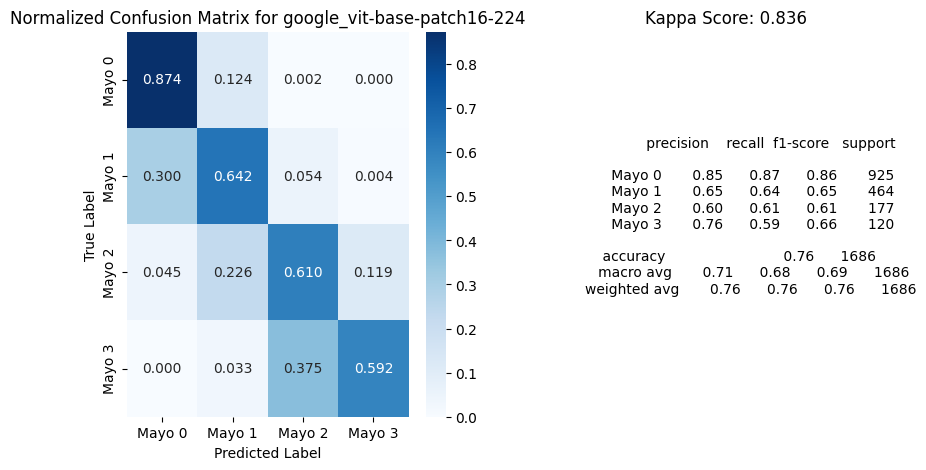

Evaluating model: microsoft_resnet-50
Accuracy: 0.7455516014234875
Cohen's Kappa Score: 0.8261945081739523
Confusion Matrix for microsoft_resnet-50:
[[740 175   8   2]
 [101 324  37   2]
 [  6  30 104  37]
 [  1   0  30  89]]
Normalized Confusion Matrix for microsoft_resnet-50:
[[0.8        0.18918919 0.00864865 0.00216216]
 [0.21767241 0.69827586 0.07974138 0.00431034]
 [0.03389831 0.16949153 0.58757062 0.20903955]
 [0.00833333 0.         0.25       0.74166667]]
Classification Report for microsoft_resnet-50:
              precision    recall  f1-score   support

      Mayo 0       0.87      0.80      0.83       925
      Mayo 1       0.61      0.70      0.65       464
      Mayo 2       0.58      0.59      0.58       177
      Mayo 3       0.68      0.74      0.71       120

    accuracy                           0.75      1686
   macro avg       0.69      0.71      0.70      1686
weighted avg       0.76      0.75      0.75      1686



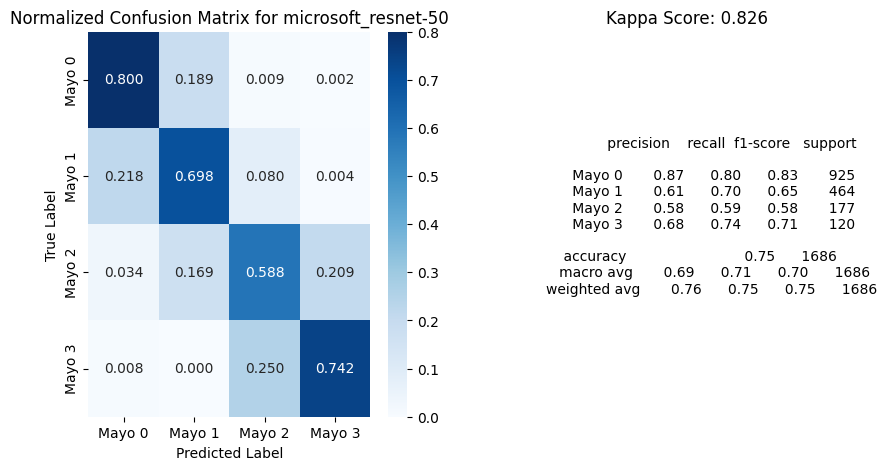

Evaluating model: google_mobilenet_v2_1.0_224
Accuracy: 0.7396204033214709
Cohen's Kappa Score: 0.8050804374523393
Confusion Matrix for google_mobilenet_v2_1.0_224:
[[858  65   0   2]
 [204 237  10  13]
 [ 22  38  48  69]
 [  4   4   8 104]]
Normalized Confusion Matrix for google_mobilenet_v2_1.0_224:
[[0.92756757 0.07027027 0.         0.00216216]
 [0.43965517 0.51077586 0.02155172 0.02801724]
 [0.12429379 0.21468927 0.27118644 0.38983051]
 [0.03333333 0.03333333 0.06666667 0.86666667]]
Classification Report for google_mobilenet_v2_1.0_224:
              precision    recall  f1-score   support

      Mayo 0       0.79      0.93      0.85       925
      Mayo 1       0.69      0.51      0.59       464
      Mayo 2       0.73      0.27      0.40       177
      Mayo 3       0.55      0.87      0.68       120

    accuracy                           0.74      1686
   macro avg       0.69      0.64      0.63      1686
weighted avg       0.74      0.74      0.72      1686



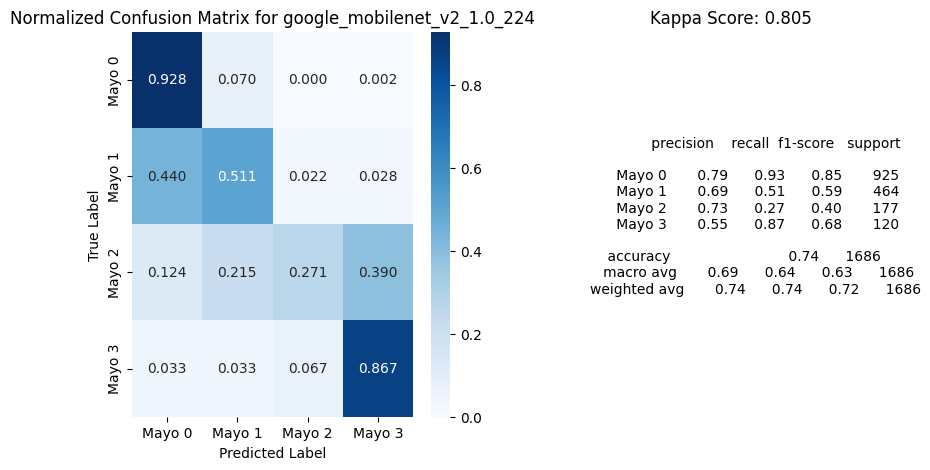

Evaluating model: nvidia_mit-b2
Accuracy: 0.7241992882562278
Cohen's Kappa Score: 0.767944079361918
Confusion Matrix for nvidia_mit-b2:
[[836  89   0   0]
 [179 280   5   0]
 [  8  95  72   2]
 [  1  20  66  33]]
Normalized Confusion Matrix for nvidia_mit-b2:
[[0.90378378 0.09621622 0.         0.        ]
 [0.38577586 0.60344828 0.01077586 0.        ]
 [0.04519774 0.53672316 0.40677966 0.01129944]
 [0.00833333 0.16666667 0.55       0.275     ]]
Classification Report for nvidia_mit-b2:
              precision    recall  f1-score   support

      Mayo 0       0.82      0.90      0.86       925
      Mayo 1       0.58      0.60      0.59       464
      Mayo 2       0.50      0.41      0.45       177
      Mayo 3       0.94      0.28      0.43       120

    accuracy                           0.72      1686
   macro avg       0.71      0.55      0.58      1686
weighted avg       0.73      0.72      0.71      1686



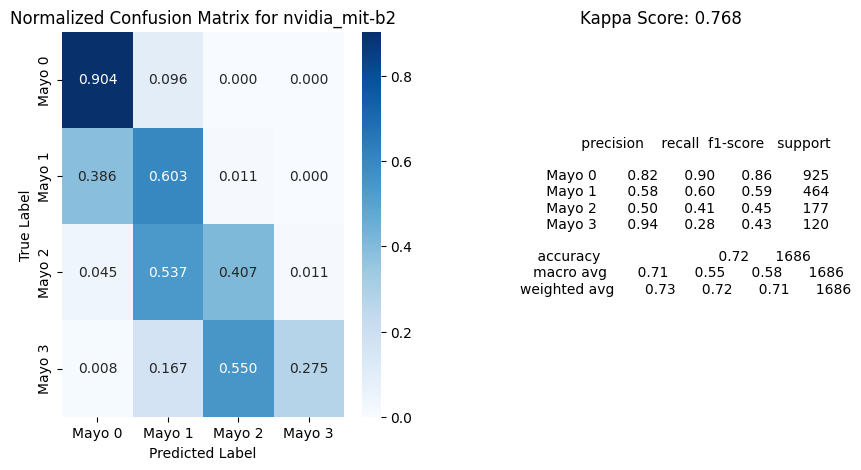

Evaluating model: mit-b2
Accuracy: 0.7111506524317912
Cohen's Kappa Score: 0.7541504285586147
Confusion Matrix for mit-b2:
[[848  77   0   0]
 [196 263   5   0]
 [  9 111  50   7]
 [  3  19  60  38]]
Normalized Confusion Matrix for mit-b2:
[[0.91675676 0.08324324 0.         0.        ]
 [0.42241379 0.56681034 0.01077586 0.        ]
 [0.05084746 0.62711864 0.28248588 0.03954802]
 [0.025      0.15833333 0.5        0.31666667]]
Classification Report for mit-b2:
              precision    recall  f1-score   support

      Mayo 0       0.80      0.92      0.86       925
      Mayo 1       0.56      0.57      0.56       464
      Mayo 2       0.43      0.28      0.34       177
      Mayo 3       0.84      0.32      0.46       120

    accuracy                           0.71      1686
   macro avg       0.66      0.52      0.56      1686
weighted avg       0.70      0.71      0.69      1686



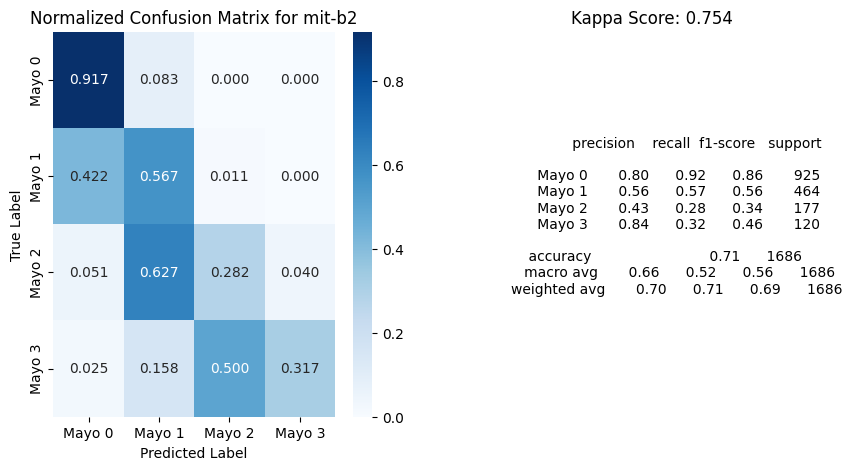

Evaluating model: google_vit-base-patch16-224-in21k
Accuracy: 0.7781731909845789
Cohen's Kappa Score: 0.849294014479799
Confusion Matrix for google_vit-base-patch16-224-in21k:
[[816 106   3   0]
 [120 315  25   4]
 [  7  41 102  27]
 [  0   2  39  79]]
Normalized Confusion Matrix for google_vit-base-patch16-224-in21k:
[[0.88216216 0.11459459 0.00324324 0.        ]
 [0.25862069 0.67887931 0.05387931 0.00862069]
 [0.03954802 0.23163842 0.57627119 0.15254237]
 [0.         0.01666667 0.325      0.65833333]]
Classification Report for google_vit-base-patch16-224-in21k:
              precision    recall  f1-score   support

      Mayo 0       0.87      0.88      0.87       925
      Mayo 1       0.68      0.68      0.68       464
      Mayo 2       0.60      0.58      0.59       177
      Mayo 3       0.72      0.66      0.69       120

    accuracy                           0.78      1686
   macro avg       0.72      0.70      0.71      1686
weighted avg       0.78      0.78      0.78      1

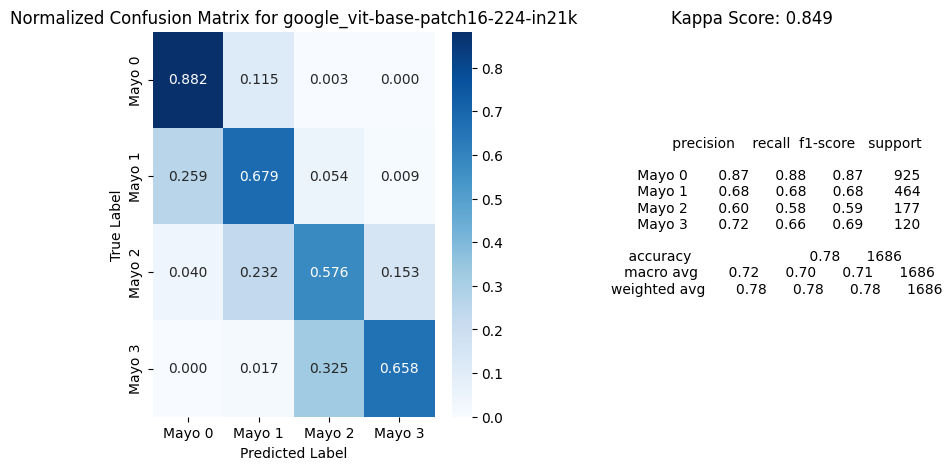

In [2]:
from transformers import AutoConfig, AutoImageProcessor, AutoModelForImageClassification
import torch
import os
import time , gc

models_checkpoints_root = '/home/qzhao9/code/9800/gradproj/experiments/runs/hf_img_classifier'
models = os.listdir(models_checkpoints_root)
print(models)

img_root = '/home/qzhao9/datasets/LIMUC/test'

# accelerator = Accelerator()
for model_name in models: #['microsoft_resnet-50']:
    print(f"Evaluating model: {model_name}")
    model_path = os.path.join(models_checkpoints_root, model_name,'best_full')
    config = AutoConfig.from_pretrained(
        model_path,
        finetuning_task="image-classification",
        )

    model = AutoModelForImageClassification.from_pretrained(
                model_path,
                config=config                  
                )
    
    image_processor = AutoImageProcessor.from_pretrained(
                model_path,
                use_fast=True,
                kwargs={"do_normalize": False,"do_rescale":False  }   
                )
    
    model.eval()
    model.to(device='cuda')
    # image_processor.to(device='cuda')
    image_processor.do_normalize = False
    image_processor.do_rescale = False
    # print(image_processor)
    calculate_metrics_hf(image_processor, model, img_root, model_name)
    model = None  # free up memory
    image_processor = None
    # print(torch.cuda.mem_get_info())
    torch.cuda.empty_cache()
    time.sleep(5)
    gc.collect()
    time.sleep(5)
    gc.collect()
    #/home/qzhao9/code/9800/gradproj/experiments/runs/hf_img_classifier/vit-base-patch16-224/best
    #/home/qzhao9/code/9800/gradproj/experiments/runs/hf_img_classifier/mit-b2/best



In [9]:
image_processor

ViTImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "disable_grouping": null,
  "do_center_crop": null,
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_pad": null,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "input_data_format": null,
  "pad_size": null,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "shortest_edge": 384
  }
}

In [10]:
from PIL import Image
img_path = ['/home/qzhao9/datasets/LIMUC/test/Mayo 3/UC_patient_44_12.bmp',
            '/home/qzhao9/datasets/LIMUC/test/Mayo 3/UC_patient_44_11.bmp']
input = image_processor(images=[Image.open(p).convert('RGB') for p in img_path], return_tensors="pt")
output = model(**input)
print(output)
predicted_class_idx = output.logits.argmax(-1).tolist()
print("Predicted class index:", [config.id2label[idx] for idx in predicted_class_idx])

TypeError: 'NoneType' object is not callable

Cohen's Kappa Score: 0.781544674807167
Confusion Matrix for HF-Classifier:
[[624 299   2   0]
 [ 50 384  28   2]
 [  2  57 108  10]
 [  0   5  61  54]]
Normalized Confusion Matrix for HF-Classifier:
[[0.67459459 0.32324324 0.00216216 0.        ]
 [0.10775862 0.82758621 0.06034483 0.00431034]
 [0.01129944 0.3220339  0.61016949 0.05649718]
 [0.         0.04166667 0.50833333 0.45      ]]
Classification Report for HF-Classifier:
              precision    recall  f1-score   support

      Mayo 0       0.92      0.67      0.78       925
      Mayo 1       0.52      0.83      0.64       464
      Mayo 2       0.54      0.61      0.57       177
      Mayo 3       0.82      0.45      0.58       120

    accuracy                           0.69      1686
   macro avg       0.70      0.64      0.64      1686
weighted avg       0.76      0.69      0.70      1686



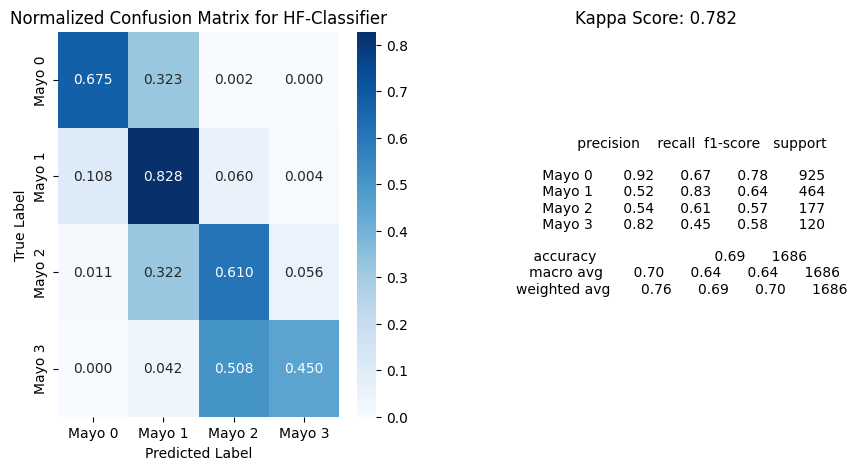

In [ ]:
img_root = '/home/qzhao9/datasets/LIMUC/test'
model.eval()
calculate_metrics_hf(image_processor, model, img_root, 'HF-Classifier')